# Medical Insurance Cost Prediction

**Project Phase 8 — Documentation & Deployment**

This notebook presents the complete reproducible workflow for predicting annual
medical insurance charges with Linear Regression. It covers data inspection,
cleaning, categorical encoding, exploratory analysis, model training, evaluation,
prediction examples, and artifact export for the Gradio deployment application.

**Dataset:** Medical Cost Personal Dataset — 1,338 records and seven columns.

In [10]:
import pandas as pd

## 1. Dataset loading and inspection

The source data contains age, sex, BMI, number of children, smoking status,
region, and billed medical charges. The code supports both Google Colab and the
repository's local `data/` folder.

In [11]:
from pathlib import Path

data_path = Path('/content/insurance.csv')
if not data_path.exists():
    data_path = Path('../data/insurance.csv')

df = pd.read_csv(data_path)
print("Dataset loaded successfully from:", data_path)

Dataset loaded successfully!


In [12]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.shape

(1338, 7)

In [14]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New shape:", df.shape)

Duplicates removed successfully!
New shape: (1337, 7)


In [20]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data preprocessing

One duplicated record is removed. The dataset has no missing values. Categorical
features are one-hot encoded with `drop_first=True`, producing eight model inputs
and avoiding redundant dummy columns.

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

In [23]:
bool_columns = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

In [24]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [25]:
df_encoded.dtypes

,0
age,int64
bmi,float64
children,int64
charges,float64
sex_male,int64
smoker_yes,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64


In [26]:
print("Final dataset shape:", df_encoded.shape)

Final dataset shape: (1337, 9)


In [27]:
print(df_encoded.isnull().sum())

print("\nTotal missing values:")
print(df_encoded.isnull().sum().sum())

age                 0
bmi                 0
children            0
charges             0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

Total missing values:
0


In [28]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [29]:
print("Feature columns:")
print(X.columns)

print("\nTarget variable:")
print(y.name)

Feature columns:
Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

Target variable:
charges


In [30]:
print("Dataset successfully cleaned and prepared for Machine Learning!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset successfully cleaned and prepared for Machine Learning!
Features shape: (1337, 8)
Target shape: (1337,)


## 3. Exploratory data analysis

The visual analysis examines how age, BMI, and smoking status relate to charges,
followed by a correlation matrix for the encoded variables.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

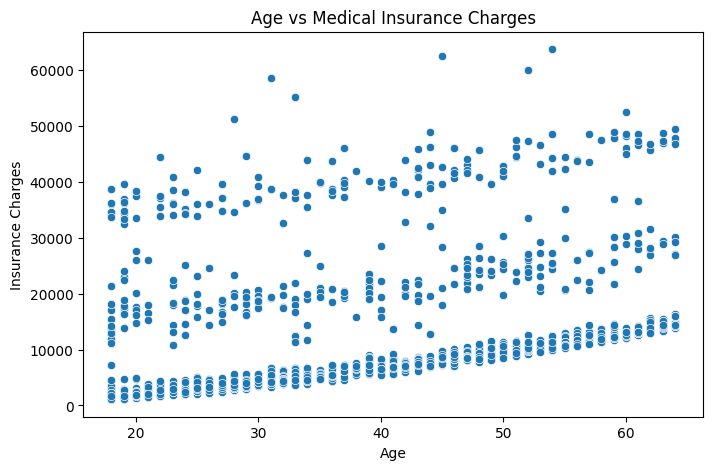

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges'
)

plt.title('Age vs Medical Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.show()

### Observation
Insurance charges generally tend to increase as age increases. However,
there is considerable variation, which indicates that age is not the only
factor affecting medical insurance costs.

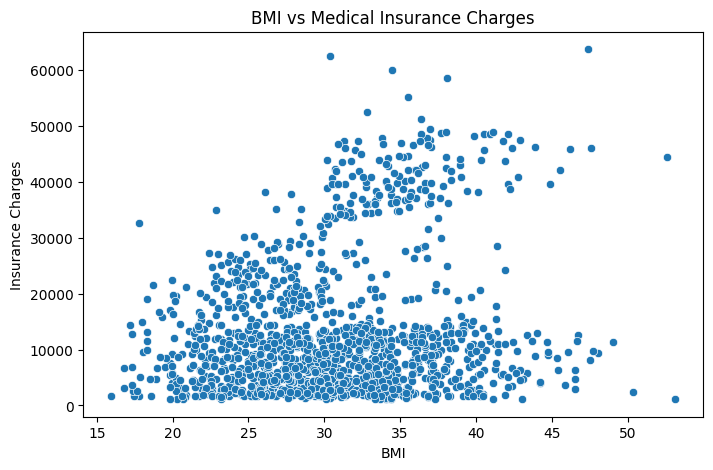

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges'
)

plt.title('BMI vs Medical Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.show()

### Observation
Higher BMI values can be associated with higher insurance charges,
although the relationship is not equally strong for every individual.
Other factors such as smoking status may also influence the charges.

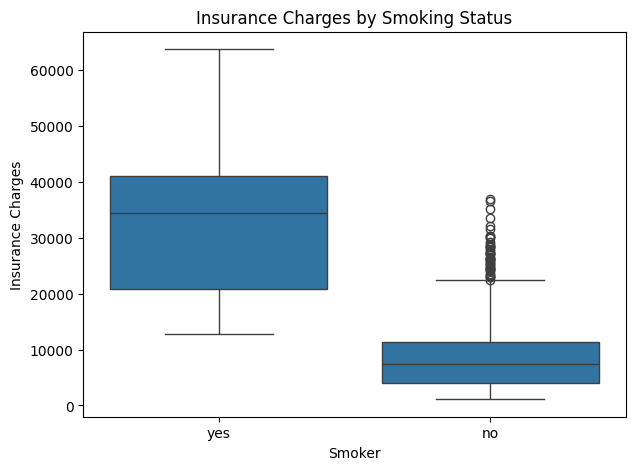

In [34]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='smoker',
    y='charges'
)

plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Insurance Charges')
plt.show()

### Observation
Smokers generally have substantially higher insurance charges than
non-smokers. This suggests that smoking status may be one of the most
important features for predicting medical insurance costs.

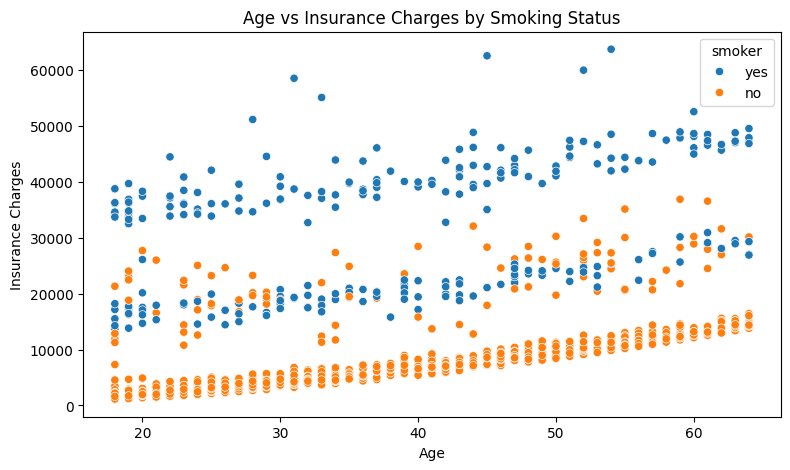

In [35]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker'
)

plt.title('Age vs Insurance Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.show()

### Observation
Insurance charges tend to increase with age, but smokers generally have
much higher charges compared with non-smokers across different age
groups. This shows that both age and smoking status may be useful
predictors.

In [36]:
correlation = df_encoded.corr()

correlation

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,1.000000,0.109344,0.041536,0.298308,-0.019814,-0.025587,0.001495,-0.012311,0.009415
bmi,0.109344,1.000000,0.012755,0.198401,0.046397,0.003746,-0.136138,0.270057,-0.006211
children,0.041536,0.012755,1.000000,0.067389,0.017848,0.007331,0.026044,-0.023492,0.021538
charges,0.298308,0.198401,0.067389,1.000000,0.058044,0.787234,-0.038695,0.073578,-0.043637
sex_male,-0.019814,0.046397,0.017848,0.058044,1.000000,0.076596,-0.012482,0.017578,-0.003767
smoker_yes,-0.025587,0.003746,0.007331,0.787234,0.076596,1.000000,-0.036321,0.068282,-0.037168
region_northwest,0.001495,-0.136138,0.026044,-0.038695,-0.012482,-0.036321,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.270057,-0.023492,0.073578,0.017578,0.068282,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.006211,0.021538,-0.043637,-0.003767,-0.037168,-0.320493,-0.346614,1.000000


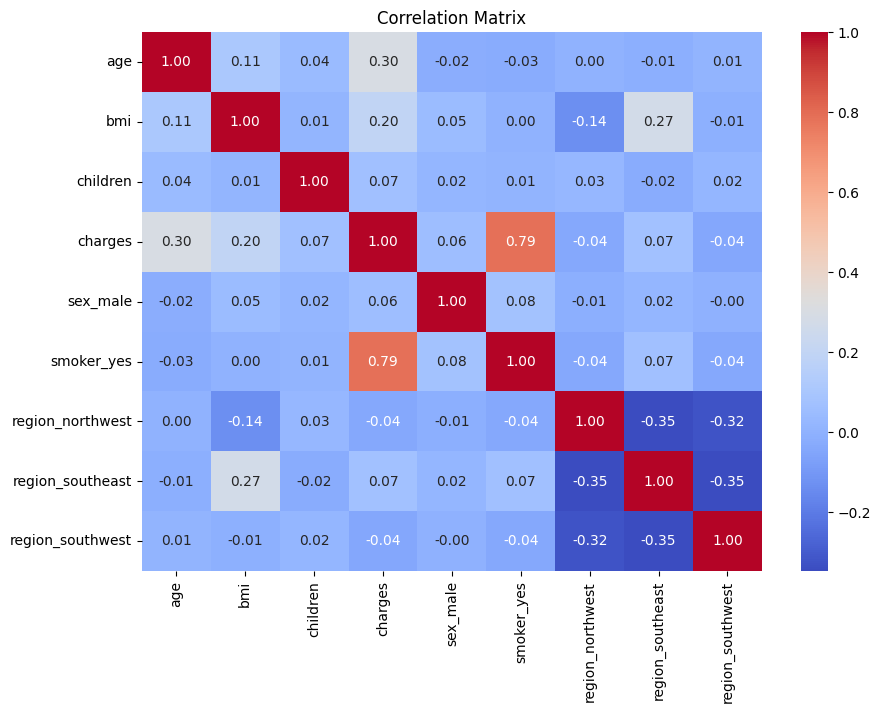

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [38]:
charges_correlation = correlation['charges'].sort_values(ascending=False)

charges_correlation

,charges
charges,1.000000
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_northwest,-0.038695
region_southwest,-0.043637


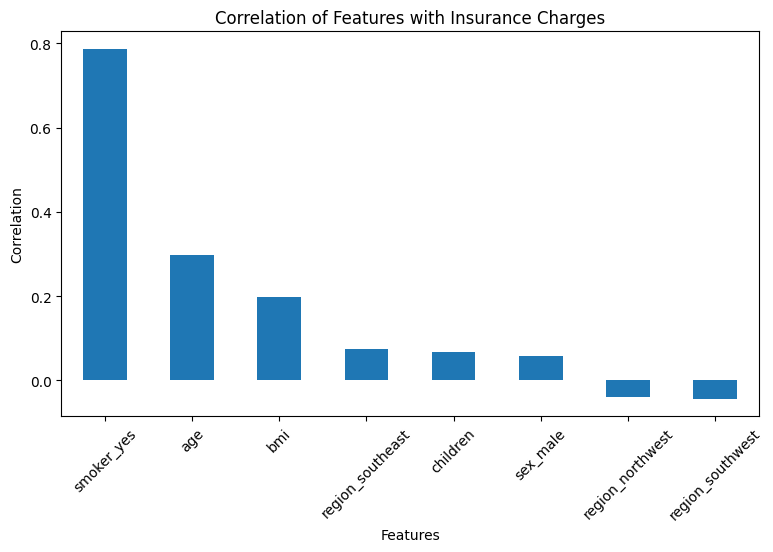

In [39]:
charges_correlation.drop('charges').plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Correlation of Features with Insurance Charges')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

## Important Observations

1. **Smoking status has a strong relationship with insurance charges.**
   Smokers generally have much higher medical insurance costs than
   non-smokers.

2. **Age has a positive relationship with insurance charges.**
   Insurance costs generally increase as individuals become older.

3. **BMI also shows a relationship with insurance charges.**
   Individuals with higher BMI can have higher medical expenses,
   although the relationship varies across the dataset.

4. **Smoking status appears to be one of the most important features**
   for predicting insurance charges.

5. The correlation analysis helps identify which numerical features have
   stronger linear relationships with the target variable `charges`.

These findings will help in selecting useful features and understanding
how different customer characteristics may influence the predictions
made by the machine learning model.

In [40]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0         0           1                 0   
1   18  33.770         1         1           0                 0   
2   28  33.000         3         1           0                 0   
3   33  22.705         0         1           0                 1   
4   32  28.880         0         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  

Target (y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [41]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 8)
y shape: (1337,)


## 4. Model training

The prepared dataset is split into 80% training and 20% testing subsets using
`random_state=42`. A multiple Linear Regression model is fitted on the 1,069
training records.

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

In [47]:
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [48]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [49]:
results = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

results.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [50]:
results = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

results = results.round(2)

results.head(10)

,Actual Charges,Predicted Charges
0,8688.86,8143.69
1,5708.87,5737.12
2,11436.74,14369.31
3,38746.36,31745.51
4,4463.21,8962.39
5,9304.70,13149.72
6,38511.63,30446.76
7,2150.47,1453.29
8,7345.73,10633.02
9,10264.44,11318.94


In [51]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,age,248.210720
1,bmi,318.701441
2,children,533.009989
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


In [52]:
print("Model Intercept:", model.intercept_)

Model Intercept: -11092.65229594595


## 5. Model evaluation

Performance is measured on 268 unseen test records using MAE, MSE, RMSE, and R².
The fitted model explains approximately 80.69% of the variation in test charges.

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [54]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


In [55]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

comparison = comparison.round(2)

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.86,8143.69
1,5708.87,5737.12
2,11436.74,14369.31
3,38746.36,31745.51
4,4463.21,8962.39
5,9304.70,13149.72
6,38511.63,30446.76
7,2150.47,1453.29
8,7345.73,10633.02
9,10264.44,11318.94


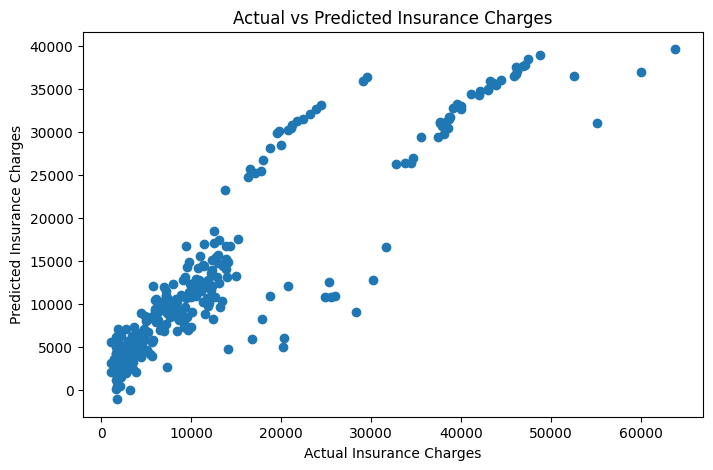

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Insurance Charges')
plt.ylabel('Predicted Insurance Charges')
plt.title('Actual vs Predicted Insurance Charges')

plt.show()

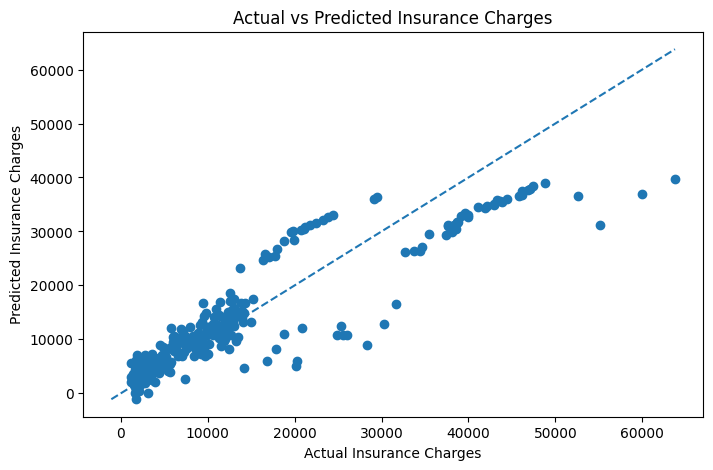

In [57]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    '--'
)

plt.xlabel('Actual Insurance Charges')
plt.ylabel('Predicted Insurance Charges')
plt.title('Actual vs Predicted Insurance Charges')

plt.show()

## 6. Interactive prediction application

The Gradio interface converts user entries into the same eight encoded features
used during training, then returns the model's estimated annual insurance cost.

In [58]:
!pip install -q gradio

In [59]:
import gradio as gr
import pandas as pd

In [60]:
def predict_insurance(age, bmi, children, gender, smoker, region):

    # Create input using the same columns used during training
    input_data = pd.DataFrame(columns=X.columns)

    input_data.loc[0] = 0

    # Numerical features
    input_data.loc[0, 'age'] = age
    input_data.loc[0, 'bmi'] = bmi
    input_data.loc[0, 'children'] = children

    # Gender encoding
    input_data.loc[0, 'sex_male'] = 1 if gender == "Male" else 0

    # Smoking encoding
    input_data.loc[0, 'smoker_yes'] = 1 if smoker == "Yes" else 0

    # Region encoding
    input_data.loc[0, 'region_northwest'] = 1 if region == "Northwest" else 0
    input_data.loc[0, 'region_southeast'] = 1 if region == "Southeast" else 0
    input_data.loc[0, 'region_southwest'] = 1 if region == "Southwest" else 0

    # Make prediction
    prediction = model.predict(input_data)[0]

    return f"Estimated Insurance Cost: ${prediction:,.2f}"

In [62]:
app = gr.Interface(
    fn=predict_insurance,

    inputs=[
        gr.Number(
            label="Age",
            value=30
        ),

        gr.Number(
            label="BMI",
            value=25.0
        ),

        gr.Number(
            label="Number of Children",
            value=0
        ),

        gr.Radio(
            ["Male", "Female"],
            label="Gender"
        ),

        gr.Radio(
            ["Yes", "No"],
            label="Smoker"
        ),

        gr.Dropdown(
            ["Northeast", "Northwest", "Southeast", "Southwest"],
            label="Region"
        )
    ],

    outputs=gr.Textbox(
        label="Predicted Insurance Cost"
    ),

    title="Medical Insurance Cost Prediction",

    description=(
        "Enter customer information to estimate medical insurance "
        "cost using the trained Linear Regression model."
    )
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7eb2fee813a46747e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7. Phase 8 model export and deployment

The following cell saves the fitted model and the exact feature order required by
`app.py`. The committed model was exported from this notebook's trained runtime.

### Final test performance

| Metric | Result |
|---|---:|
| MAE | $4,177.05 |
| MSE | 35,478,020.68 |
| RMSE | $5,956.34 |
| R² | 0.8069 |

See the repository README for the complete findings, limitations, screenshots,
GitHub link, and live Hugging Face Spaces deployment.

In [ ]:
import json
import joblib
import sklearn

joblib.dump(model, 'insurance_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

model_metadata = {
    'model': 'LinearRegression',
    'feature_columns': list(X.columns),
    'test_size': 0.2,
    'random_state': 42,
    'rows_after_duplicate_removal': int(len(X)),
    'metrics': {
        'MAE': float(mae),
        'MSE': float(mse),
        'RMSE': float(rmse),
        'R2': float(r2),
    },
    'versions': {
        'scikit-learn': sklearn.__version__,
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'joblib': joblib.__version__,
    },
}

with open('model_metadata.json', 'w') as metadata_file:
    json.dump(model_metadata, metadata_file, indent=2)

print('Deployment artifacts saved successfully.')
print(json.dumps(model_metadata, indent=2))